In [19]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import base64
import hashlib
import json
import re
from IPython.display import Image, display

import httpx
import duckdb

from config.settings import DB_PATH, DROP_FOLDER, OLLAMA_VISION_MODEL

OLLAMA_URL = "http://localhost:11434/api/chat"
PROCESSED_DIR = DROP_FOLDER / "processed"

print(f"Model : {OLLAMA_VISION_MODEL}")
print(f"DB    : {DB_PATH}")
print(f"Drop  : {DROP_FOLDER}")

Model : qwen3-vl:latest
DB    : /Users/vvv/Projects/groundhog/data/db/groundhog.duckdb
Drop  : /Users/vvv/Projects/groundhog/data/drop


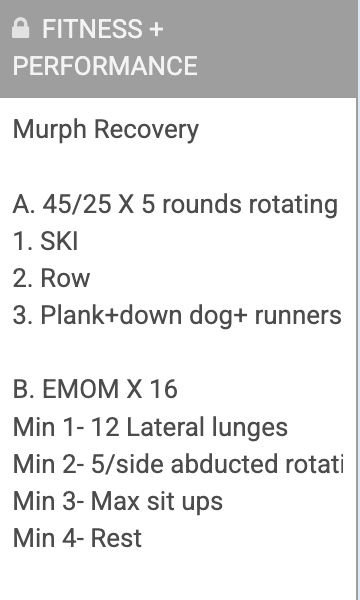

In [23]:
# --- change this to the image you want to test ---
IMAGE_PATH = DROP_FOLDER / "Screenshot 2026-05-26 at 6.10.24 AM.png"

display(Image(filename=str(IMAGE_PATH)))

In [ ]:
PROMPT = """You are extracting workout plandata from a SugarWOD screenshot.

Always return a JSON array. Each element represents one workout card.

For each workout card, return:
{
  "day_of_week": <"MON"|"TUE"|"WED"|"THU"|"FRI"|"SAT"|"SUN" — from the column header, or null if single-day view>,
  "date_day": <integer day-of-month from the column header, or null if not shown>,
  "date": <"YYYY-MM-DD" if the full date is visible, otherwise null>,
  "name": <the workout card header text, e.g. "MURPH", "Deadlift 8-8-6-6-4-4-4", "HYROX (9 am and 4 pm)">,
  "category": <"Fitness"|"Performance"|"HYROX"|or other visible label, or null>,
  "structure_type": <"amrap"|"emom"|"rotating"|"for_time"|"strength"|"intervals"|null>,
  "description": <full workout text as a single string, preserving newlines as \\n>
}

structure_type rules:
- "amrap"     → text contains "AMRAP"
- "emom"      → text contains "EMOM"
- "rotating"  → text contains "rotating"
- "for_time"  → text contains "for time" or a time cap like "(15 cap)"
- "strength"  → a lift with a rep scheme like "8-8-6-6-4-4" or "5-5-5-3-3-3"
- "intervals" → timed work/rest blocks like "30 second work / 2 minute rest"
- null        → if unclear

If the screenshot shows a weekly calendar (MON–SUN columns), extract every visible workout card across all days.
If the screenshot shows a single day, extract each section (Fitness, Performance, etc.) as a separate element.

Return null for any field not visible. No explanation, just the JSON array."""

print(PROMPT)

You are extracting workout data from a SugarWOD screenshot.

Always return a JSON array. Each element represents one workout card.

For each workout card, return:
{
  "day_of_week": <"MON"|"TUE"|"WED"|"THU"|"FRI"|"SAT"|"SUN" — from the column header, or null if single-day view>,
  "date_day": <integer day-of-month from the column header, or null if not shown>,
  "date": <"YYYY-MM-DD" if the full date is visible, otherwise null>,
  "name": <the workout card header text, e.g. "MURPH", "Deadlift 8-8-6-6-4-4-4", "HYROX (9 am and 4 pm)">,
  "category": <"Fitness"|"Performance"|"HYROX"|or other visible label, or null>,
  "structure_type": <"amrap"|"emom"|"rotating"|"for_time"|"strength"|"intervals"|null>,
  "description": <full workout text as a single string, preserving newlines as \n>
}

structure_type rules:
- "amrap"     → text contains "AMRAP"
- "emom"      → text contains "EMOM"
- "rotating"  → text contains "rotating"
- "for_time"  → text contains "for time" or a time cap like "(15 ca

In [22]:
def encode_image(path):
    return base64.b64encode(path.read_bytes()).decode("utf-8")

def query_ollama(image_path):
    payload = {
        "model": OLLAMA_VISION_MODEL,
        "messages": [{"role": "user", "content": PROMPT, "images": [encode_image(image_path)]}],
        "stream": False,
    }
    response = httpx.post(OLLAMA_URL, json=payload, timeout=600.0)
    response.raise_for_status()
    return response.json()["message"]["content"]

raw = query_ollama(IMAGE_PATH)
print(raw)

[
  {
    "day_of_week": null,
    "date_day": null,
    "date": null,
    "name": "A. 45/25 X 5 rounds rotating",
    "category": "FITNESS + PERFORMANCE",
    "structure_type": "rotating",
    "description": "A. 45/25 X 5 rounds rotating\n1. SKI\n2. Row\n3. Plank+down dog+ runners"
  },
  {
    "day_of_week": null,
    "date_day": null,
    "date": null,
    "name": "B. EMOM X 16",
    "category": "FITNESS + PERFORMANCE",
    "structure_type": "emom",
    "description": "B. EMOM X 16\nMin 1- 12 Lateral lunges\nMin 2- 5/side abducted rotati\nMin 3- Max sit ups\nMin 4- Rest"
  }
]


In [ ]:
from datetime import date

def parse_workouts(raw):
    match = re.search(r"\[.*\]", raw, re.DOTALL)
    if not match:
        print("No JSON array found in response.")
        return []
    try:
        return json.loads(match.group())
    except json.JSONDecodeError as e:
        print(f"JSON parse error: {e}")
        return []

today = date.today()

workouts = parse_workouts(raw)
for w in workouts:
    if not w.get("date"):
        w["date"] = today.isoformat()
    if not w.get("date_day"):
        w["date_day"] = today.day
    if not w.get("day_of_week"):
        w["day_of_week"] = today.strftime("%a").upper()

print(f"{len(workouts)} workout(s) parsed\n")
for w in workouts:
    print(f"{w.get('day_of_week', '')} {w.get('date_day', '')} | {w.get('name')} | {w.get('structure_type')} | {w.get('category')}")
    print(f"  {w.get('description', '')[:120]}")
    print()

types: rotating, emom, amrap

30/30 X 8 rounds rotating

1. BB Deadlift
2. Lateral step ups
3. Wall sit with adduction
4. DB FR reverse lunges

